# Homework 6 solutions

In [1]:
import unyt
import matplotlib.pyplot as plt
import numpy as np

We'll need our Lane-Emden solver, so we'll paste it here:

In [2]:
class Polytrope:
    """a polytrope of index n"""
    def __init__(self, n, h0=1.e-2, tol=1.e-12):
        self.n = n
        self.xi = []
        self.theta = []
        self.dtheta_dxi = []
        
        self._integrate(h0, tol)

    def _integrate(self, h0, tol):
        """integrate the Lane-Emden system"""

        # our solution vector q = (y, z)
        q = np.zeros(2, dtype=np.float64)
        xi = 0.0

        h = h0

        # initial conditions
        q[0] = 1.0
        q[1] = 0.0

        while h > tol:
            # 4th order RK integration -- first find the slopes
            k1 = self._rhs(xi, q)
            k2 = self._rhs(xi+0.5*h, q+0.5*h*k1)
            k3 = self._rhs(xi+0.5*h, q+0.5*h*k2)
            k4 = self._rhs(xi+h, q+h*k3)

            # now update the solution to the new xi
            q += (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
            xi += h

            # set the new stepsize--our systems is always convex
            # (theta'' < 0), so the intersection of theta' with the
            # x-axis will always be a conservative estimate of the
            # radius of the star.  Make sure that the stepsize does
            # not take us past that.
            R_est = xi - q[0]/q[1]

            if xi + h > R_est:
                h = -q[0]/q[1]

            # store the solution:
            self.xi.append(xi)
            self.theta.append(q[0])
            self.dtheta_dxi.append(q[1])

        self.xi = np.array(self.xi)
        self.theta = np.array(self.theta)
        self.dtheta_dxi = np.array(self.dtheta_dxi)

    def _rhs(self, xi, q):
        """ the righthand side of the LE system, q' = f"""

        f = np.zeros_like(q)

        # y' = z
        f[0] = q[1]
        
        # for z', we need to use the expansion if we are at xi = 0,
        # to avoid dividing by 0
        if xi == 0.0:
            f[1] = (2.0/3.0) - q[0]**self.n
        else:
            f[1] = -2.0*q[1]/xi - q[0]**self.n

        return f

    def get_params(self):
        """ return the standard polytrope parameters xi_1,
        and [-xi**2 theta']_{xi_1} """
        xi1 = self.xi[-1]
        p2 = -xi1**2 * self.dtheta_dxi[-1]
        return xi1, p2

    def plot(self):
        """ plot the solution """
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.plot(self.xi, self.theta, label=r"$\theta$")
        ax.plot(self.xi, self.theta**self.n, label=r"$\rho/\rho_c$")
        ax.set_xlabel(r"$\xi$")
        ax.legend(frameon=False)
        return fig

## 1. Lane-Emden asymptotics

The Lane-Emden equation is:

$$\frac{1}{\xi^2} \frac{d}{d\xi} \left ( \xi^2 \frac{d\theta}{d\xi} \right ) = -\theta^n$$

we want a series expansion near $\xi = 0$.

Our boundary conditions are $\theta(0) = 1$ and $\theta(\xi) = \theta(-\xi)$.

Let's write

$$\theta(\xi) = \sum_{k=0}^\infty a_k \xi^k$$

The our boundary conditions imply:

* $\theta(0) = 1 \rightarrow a_0 =1$
* $\theta(\xi) = \theta(-\xi) \rightarrow$ all odd coefficients are $0$

This leaves us with

$$\theta(\xi) = 1 + a_2 \xi^2 + a_4 \xi^4 + a_6 \xi^6 + \ldots$$

Now let's compute the derivatives:

$$\frac{d\theta}{d\xi} = 2 a_2 \xi + 4 a_4 \xi^3 + 6 a_6 \xi^5 + \ldots$$

and then for the second derivative:

$$\frac{d}{d\xi} \left (\xi^2 \frac{d\theta}{d\xi} \right ) = 6 a_2 \xi^2 + 20 a_4 \xi^4 + 42 a_6 \xi^6 + \ldots$$

and finally:

$$\frac{1}{\xi^2} \frac{d}{d\xi} \left ( \xi^2 \frac{d\theta}{d\xi} \right ) \sim 6 a_2 + 20a_4 \xi^2 + 42 a_6 \xi^4 + \ldots$$

Now consider the righthand side:

$$\theta^n = \left ( 1 + a_2 \xi^2 + a_4 \xi^4 + a_6 \xi^6 + \ldots \right )^n$$

using a binomial expansion, we can write this as:

$$\theta^n \sim 1 + n \left (a_2 \xi^2 + a_4 \xi^4 + a_6 \xi^6 + \ldots \right ) + \frac{n(n-1)}{2} \left (a_2 \xi_2^2 + a_4 \xi^4 + a_6 \xi^6 + \ldots \right )^2 + \ldots$$

we can write the $\left ( \ldots \right )^2$ term out as:

\begin{align*}
\left (a_2 \xi_2^2 + a_4 \xi^2 + a_6 \xi^6 + \ldots \right )^2 &= \xi^4 \left (a_2 + a_4 \xi^2 + a_6 \xi^4 + \ldots \right )^2 \\
                                                   &\sim \xi^4 \left [ a_2^2 + 2 a_2 (a_4 \xi^2 + a_6 \xi^4 + \ldots) + \mathcal{O}(\xi^4)\right ]
\end{align*}

Then putting it all together (keeping terms to $\mathcal{O}(\xi^4)$, we have:

$$6a_2 + 20 a_4 \xi^2 + 42 a_6 \xi^4 \sim -1 - n(a_2\xi^2 + a_4 \xi^4) - \frac{n(n-1)}{2} a_2^2 \xi^4$$

Grouping by power, we have:

$$6a_2 = -1$$

$$20 a_4 = -n a_2$$

$$42 a_6 = -n a_4 - \frac{n(n-1)}{2} a_2^2$$

This has the solution:

$$a_2 = -\frac{1}{6}$$

$$a_4 = \frac{n}{120}$$

$$a_6 = -\frac{n (8n - 5)}{15120}$$

giving:

$$\theta(\xi) \sim 1 - \frac{1}{6}\xi^2 + \frac{n}{120} \xi^4 - \frac{n(8n-5)}{15120} \xi^6 + \ldots$$

Let's see how well this does compared to the integrated solution

In [3]:
p = Polytrope(3)

In [4]:
def theta_approx(xi, n=3):
    return 1 - (1./6.) * xi**2 + (n / 120.) * xi**4 - n * (8 * n - 5) / 15120. * xi**6

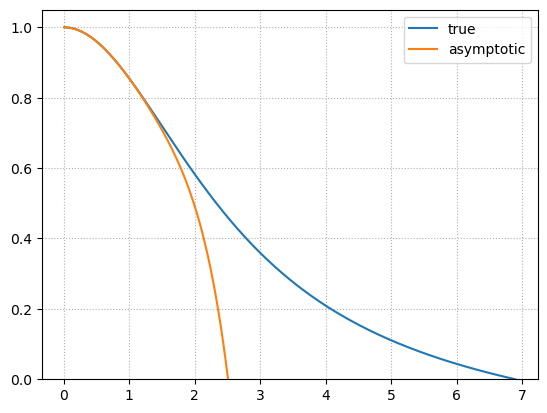

In [5]:
fig, ax = plt.subplots()
ax.plot(p.xi, p.theta, label="true")
ax.plot(p.xi, theta_approx(p.xi, n=p.n), label="asymptotic")
ax.set_ylim(0, 1.05)
ax.grid(ls=":")
ax.legend()

## 2. Stellar stability

We want to understand how a star responds when we perturb it.  We are going to use homologous compression, assuming that each radial shell moves by the same factor:

$$r^\prime = r_0 (1 - \epsilon)$$

### a. density response

The initial mass of a shell is 

$$dm = 4\pi r_0^2 \rho dr_0$$

and after perturbing, it becomes:

$$dm = 4\pi r_0^2 \rho dr_0 = 4\pi r_0^2 (1 - \epsilon)^2 \rho' d[r_0 (1 - \epsilon)]
   \sim 4\pi r_0^2 (1 - 3\epsilon) \rho^\prime dr_0$$

Since the mass in the shell is unchanged by compression, this shows that

$$\rho^\prime \sim \frac{\rho}{1 - 3\epsilon} \sim \rho (1 + 3\epsilon)$$


### b. pressure response

Now we can use HSE to find the pressure response.  For some mass-shell $m_\mathrm{sh}$ in the star,
we can integrate to the surface (where $m = M$):

$$P_{\mathrm{HSE,0}}(m_\mathrm{sh}) = \int_{m_\mathrm{sh}}^M \frac{Gm dm}{4\pi r_0^4}$$

when we perturb the radial coordinate, the mass doesn't change, so the perturbed
pressure is:

$$P^\prime_\mathrm{HSE}(m_\mathrm{sh}) = \int_{m_\mathrm{sh}}^M \frac{Gm dm}{4\pi r_0^4 (1 - \epsilon)^4} \sim (1 + 4\epsilon) P_{\mathrm{HSE},0}(m_\mathrm{sh})$$




### c. adiabaticity

If this compression is done adiabatically, then:

$$P = K \rho^{\Gamma_1}$$

so the gas pressure responds under compression as:

$$P_\mathrm{gas}^\prime = K {\rho^\prime}^{\Gamma_1} \sim K [\rho_0 (1 + 3\epsilon)]^{\Gamma_1} = P_{\mathrm{gas},0} ( 1 + 3\Gamma_1 \epsilon)$$

### d. stability

To be stable, we require

$$P^\prime_\mathrm{gas} > P^\prime_\mathrm{HSE}$$

or

$$P_0 (1 + 3\Gamma_1 \epsilon) > P_0 (1 + 4\epsilon)$$

Therefore, stability requires:

$$\frac{1 + 3\Gamma_1 \epsilon}{1 + 4\epsilon} > 1$$

or $\Gamma_1 > 4/3$

## 3. Fully convective stars

We want to consider the structure of a $0.3~M_\odot$ fully convective star.  We know that $\gamma = 5/3$ (corresponding to a polytropic index $n = 3/2$), and we are told to take $\mu = 0.6$.

We'll need our Lane-Emden soluition, which I'll copy from our notes here:

### a. central density

From the ideal gas law and the polytropic equation of state, we have:

$$P_c = K \rho_c^{1+1/n} = \frac{\rho_c k T_c}{\mu m_u}$$

taking $n = 3/2$, we have:

$$\rho_c = \left ( \frac{k T_c}{\mu m_u K} \right )^{3/2}$$

### b. polytropic constant

From polytropes (taking $n = 3/2$), we know:

$$M = \frac{1}{\sqrt{4\pi}} \left ( \frac{5}{2G} \right )^{3/2} K^{3/2} \rho_c^{1/2} M_{3/2}$$

where $M_{3/2} = -\xi_1^2 d\theta/d\xi |_{\xi_1}$ is computed from the polytrope solutions.

Inserting our central density, we have:

$$\frac{M}{M_{3/2}} = \frac{1}{\sqrt{4\pi}} \left ( \frac{5}{2G} \right)^{3/2} K^{3/2} \left (\frac{k T_c}{\mu m_u K} \right )^{3/4}$$

or solving for $K$:

$$K = \left [ \sqrt{4\pi} \left (\frac{2G}{5} \right)^{3/2} \frac{M}{M_{3/2}} \left (\frac{\mu m_u}{k T_c} \right)^{3/4} \right ]^{4/3}$$

Now we can put in some numbers.  We are assuming a central temperature of $T_c = 10^7~\mathrm{K}$.

In [6]:
k = unyt.kb_cgs
G = unyt.G_cgs
M = 0.3 * unyt.solar_mass_cgs
T = 1.e7 * unyt.K
mu = 0.6
m_u = (1.0 * unyt.atomic_mass_unit).in_cgs()

In [7]:
p = Polytrope(1.5)
xi1_32, M_32 = p.get_params()

In [8]:
K = (np.sqrt(4*np.pi) * (2 * G / 5)**1.5 * (M / M_32) * (mu * m_u / (k * T))**0.75)**(4./3.)

In [9]:
K.in_cgs()

unyt_quantity(3.68728078e+13, 'cm**4/(g**(2/3)*s**2)')

### c. Plotting

To plot things in physical units, we need to know the central density, which we can now compute

In [10]:
rho_c = (k * T / (mu * m_u * K))**1.5
rho_c.in_cgs()

unyt_quantity(230.39075645, 'g/cm**3')

In [11]:
n = 1.5
P_c = K * rho_c**(1 + 1/n)
P_c

unyt_quantity(3.19262537e+17, 'g/(cm*s**2)')

We also need the $\alpha$ scaling to convert the dimensionless radius into physical radius,

$$\alpha = \left [ \frac{(n+1) P_c}{4\pi G\rho_c^2} \right ]^{1/2}$$

In [12]:
alpha = np.sqrt(((n + 1) * P_c) / (4 * np.pi * G * rho_c**2))
alpha

unyt_quantity(4.23426757e+09, 'cm')

The the radius of the star is 

$$R = \alpha \xi_1$$

In [13]:
R = alpha * xi1_32
R

unyt_quantity(1.54709709e+10, 'cm')

We previously looked at a $0.3~M_\odot$ star with MESA.  Let's see how this compares (we'll use the model from the main sequence).

In [14]:
import mesa_reader as mr

In [15]:
profile = mr.MesaData("M0.3_default_profile8.data")

In [16]:
rho_c_mesa = 10**profile.logRho[-1]
rho_c_mesa

np.float64(154.51865875668517)

In [17]:
P_c_mesa = profile.pressure[-1]
P_c_mesa

np.float64(1.3929629957845242e+17)

In [18]:
K_mesa = P_c_mesa / rho_c_mesa**(1 + 1/n)
K_mesa /1.e13

np.float64(3.1306753222508052)

In [19]:
R_mesa = profile.radius[0] * unyt.solar_radius
R_mesa.in_cgs()

unyt_quantity(2.21212542e+10, 'cm')

So we are pretty close.

Now we can plot the density.  First get the dimenionless solution from the Lane-Emden equation

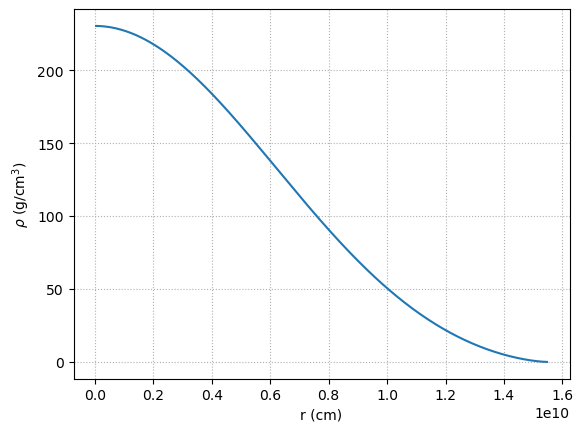

In [20]:
xi = p.xi
theta = p.theta

r_poly = alpha * xi
rho_poly = rho_c * theta**n

fig, ax = plt.subplots()
ax.plot(r_poly, rho_poly)
ax.set_xlabel("r (cm)")
ax.set_ylabel(r"$\rho$ (g/cm$^3$)")
ax.grid(ls=":")

We can get temperature from the ideal gas law:

$$T = \frac{\mu m_u P}{k \rho} = \frac{\mu m_u K \rho^{1 + 1/n}}{k \rho} = \frac{\mu m_u K \rho^{1/n}}{k}$$

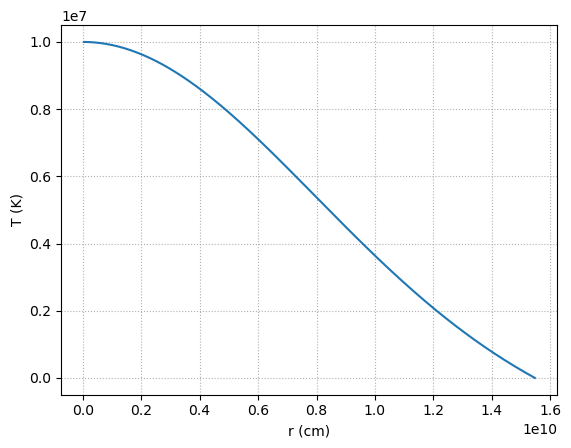

In [21]:
T_poly = mu * m_u * K * rho_poly**(1/n) / k

fig, ax = plt.subplots()

ax.plot(r_poly, T_poly)
ax.set_xlabel("r (cm)")
ax.set_ylabel("T (K)")
ax.grid(ls=":")

### d. luminosity

For the luminosity, we can just to a simple Riemann sum.  We'll just take X = 1

In [22]:
X = 1
L = 0
for n in range(len(r_poly)-1):
    T9 = T_poly[n] / (1.e9 * unyt.K)
    rho = rho_poly[n]
    r = r_poly[n]
    dr = r_poly[n+1] - r_poly[n]

    # the rho and T9 in the eps expression should be dimensionless, and then we'll
    # attach the proper units
    eps_pp = 2.4e4 * float(rho) * X**2 * T9**(-2./3.) * np.exp(-3.38 * T9**(-1./3.)) * unyt.erg / unyt.g / unyt.s
    
    L += 4 * np.pi * r**2 * rho * eps_pp * dr

In [23]:
L /  (1  *unyt.solar_luminosity).in_cgs()

unyt_quantity(0.30268346, '(dimensionless)')

We see that the luminosity is about $0.3~L_\odot$